## DATA ENGINEERING

This is the data engineering notebook that encompasses all initial data exploration and curation for this project.

### 1.0 Imports & Configurations

In [14]:
import json
from pymongo import MongoClient, UpdateOne, DeleteOne
import re
import pymongo
from datetime import datetime
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

#### 1.1 Connecting to MongoDB

In [15]:
# Connect to local MongoDB
client = MongoClient('localhost', 27017)

# Create/access database and collection
db = client['credit_db']
collection = db['applications_raw']

# Clear collection for fresh start
collection.drop()

print("Connected to MongoDB!")
print(f"   Database: {db.name}")
print(f"   Collection: applications_raw")

Connected to MongoDB!
   Database: credit_db
   Collection: applications_raw


#### 1.2 Loading the JSON file with the raw data into the server

In [16]:
file_path = 'raw_credit_applications.json'
with open(file_path, 'r') as f:
    data = json.load(f)

#### 1.3 Field '_id' Name Configuration 

In order to be able to detect duplicates and have them (initially) in the database without MongoDB throwing errors, we have changed the '_id' field into 'app_id'. 

In [17]:
for doc in data:
    if '_id' in doc:
        doc['app_id'] = doc.pop('_id')

#### 1.4 Inserting Data into Our NoSQL Database

In [18]:
if data:
    collection.insert_many(data)
total_records = collection.count_documents({})
print(f"Total records ingested: {total_records}\n")

Total records ingested: 502



### 2.0 Data Exploration 

#### 2.1 Exploring Data Types

In order to get a sense of the dataset we are working with, we will first look into what datatypes are actually contained in each field, and see if it matches the data schema given to us in the project description document.

--- DATA TYPES FOUND PER FIELD ---
_id: str
applicant_info: dict
applicant_info.date_of_birth: str
applicant_info.email: str
applicant_info.full_name: str
applicant_info.gender: str
applicant_info.ip_address: str
applicant_info.ssn: str
applicant_info.zip_code: str
decision: dict
decision.approved_amount: int
decision.interest_rate: float
decision.loan_approved: bool
decision.rejection_reason: str
financials: dict
financials.annual_income: float, int, str
financials.annual_salary: int
financials.credit_history_months: int
financials.debt_to_income: float
financials.savings_balance: int
loan_purpose: str
notes: str
processing_timestamp: str
spending_behavior: list
spending_behavior.amount: int
spending_behavior.category: str

--- VISUALIZING DATA TYPES (WITH HIGHLIGHTS) ---


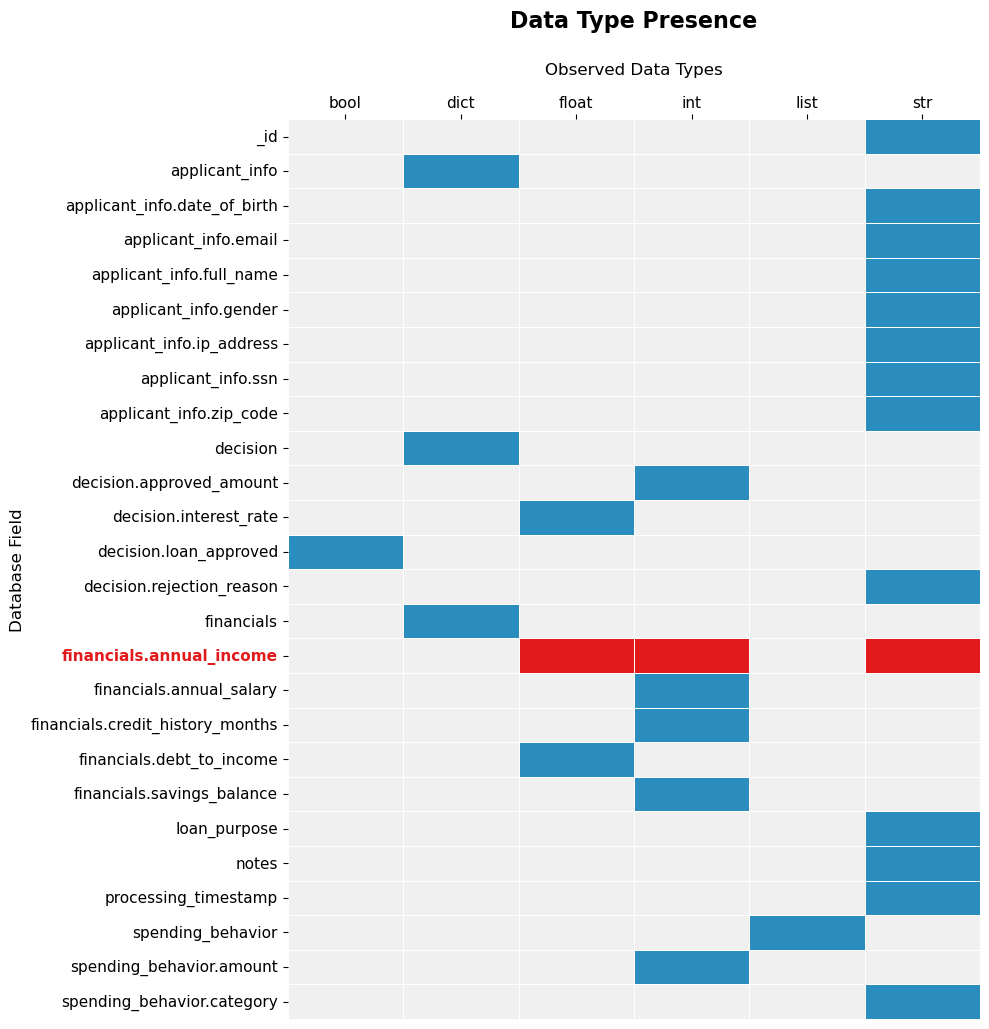

In [19]:
with open(file_path, 'r') as f:
    data = json.load(f)

# Dictionary to store a set of unique data types for each field
field_types = {}

def record_type(path, value):
    """Records the data type of the value at the given schema path."""
    if path not in field_types:
        field_types[path] = set()
    
    field_types[path].add(type(value).__name__)

def parse_document(doc, prefix=""):
    """Recursively traverses the JSON document to extract paths and types."""
    for key, value in doc.items():
        # Build the dot-notation path
        path = f"{prefix}.{key}" if prefix else key
        
        if isinstance(value, dict):
            # Record that this field is a dict, then dive inside it
            record_type(path, value)
            parse_document(value, path)
            
        elif isinstance(value, list):
            # Record that this field is a list
            record_type(path, value)
            
            # Dive into the elements of the array
            for item in value:
                if isinstance(item, dict):
                    # For array of objects (like spending_behavior)
                    parse_document(item, path)
                else:
                    # For array of simple values
                    record_type(f"{path}.[element]", item)
        else:
            # Base case: strings, numbers, booleans, nulls
            record_type(path, value)

# Run all documents through the parser
for doc in data:
    parse_document(doc)

# Printing the results
print("--- DATA TYPES FOUND PER FIELD ---")
for field in sorted(field_types.keys()):
    types_found = ", ".join(sorted(list(field_types[field])))
    print(f"{field}: {types_found}")

print("\n--- VISUALIZING DATA TYPES (WITH HIGHLIGHTS) ---")

if field_types:
    # 1. Find all unique data types
    all_observed_types = set()
    for types in field_types.values():
        all_observed_types.update(types)
    all_observed_types = sorted(list(all_observed_types))

    # 2. Build the matrix
    matrix_data = []
    for field in sorted(field_types.keys()):
        row_data = {'Field': field}
        for data_type in all_observed_types:
            row_data[data_type] = 1 if data_type in field_types[field] else 0
        matrix_data.append(row_data)

    df_types = pd.DataFrame(matrix_data).set_index('Field')

    # ==========================================
    # THE HIGHLIGHT TRICK
    # ==========================================
    # Loop through our DataFrame and find any field with more than 1 data type
    for field in df_types.index:
        # If the sum of the row is > 1, it means multiple data types exist!
        if df_types.loc[field].sum() > 1:
            # Change the '1's in this specific row to '2's
            df_types.loc[field] = df_types.loc[field].replace(1, 2)


    # 3. Set up the plotting canvas
    plt.figure(figsize=(10, max(8, len(df_types) * 0.4)))

    # 4. Create our custom 3-color palette
    # 0 = Absent (Light Gray)
    # 1 = Present & Consistent (Deep Blue)
    # 2 = Present & Inconsistent (Bright Red)
    custom_cmap = ListedColormap(['#f0f0f0', '#2b8cbe', '#e31a1c'])

    # Draw the heatmap
    ax = sns.heatmap(
        df_types, 
        cmap=custom_cmap, 
        cbar=False,           
        linewidths=0.5,       
        linecolor='white'
    )

    # 5. Clean up titles and labels
    plt.title('Data Type Presence', fontsize=16, pad=25, fontweight='bold')
    plt.xlabel('Observed Data Types', fontsize=12, labelpad=15)
    plt.ylabel('Database Field', fontsize=12)

    # Move X-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    # 6. BONUS: Make the Y-axis text label RED and BOLD for inconsistent fields!
    for tick_label in ax.get_yticklabels():
        field_name = tick_label.get_text()
        # If this row contains our custom '2' value, style the text
        if df_types.loc[field_name].max() == 2:
            tick_label.set_color('#e31a1c')
            tick_label.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

else:
    print("   - No data types to visualize. The dictionary is empty.")

#### 2.2 Data Type Findings 

Through our cursory exploration of data types we found out very important things about our data:
- We can see that the `annual_income` field contains float, int and str. This should be fixed.
- There exists a field called `annual_salary`, which is probably a data entry error. This field should be merged with `annual_income`.
- We found a hidden field called `notes`. We should make sure to include this field during next curation phases.

#### 2.3 Checking For Duplicate Entries

In [20]:
duplicate_pipeline = [
    {
        "$group": {
            "_id": {
                "applicant_info": "$applicant_info",
                "financials": "$financials",
                "spending_behavior": "$spending_behavior",
                "decision": "$decision",
                "loan_purpose": "$loan_purpose"
            },
            "count": {"$sum": 1},
            "duplicate_ids": {"$push": "$_id"} # Push all MongoDB IDs into an array
        }
    },
    {"$match": {"count": {"$gt": 1}}}
]

duplicates = list(collection.aggregate(duplicate_pipeline))
num_duplicates = sum([d['count'] - 1 for d in duplicates])
print(f"Duplicates found: {num_duplicates} ({(num_duplicates/total_records)*100:.2f}%)")

Duplicates found: 1 (0.20%)


Only one duplicate entry was found. We should make sure to remove this entry during the curation phase.

#### 2.4 Checking For Missing Values

The code below checks for both missing values (e.g. "ssn": "") and missing fields (e.g. the field "ssn" does not show up at all). This is done to get a sense of how much overall data is missing.


2. Missing Fields Analysis:
   - applicant_info.email: 7 missing (1.39%)
   - applicant_info.ssn: 5 missing (1.00%)
   - applicant_info.ip_address: 5 missing (1.00%)
   - applicant_info.gender: 3 missing (0.60%)
   - applicant_info.date_of_birth: 5 missing (1.00%)
   - applicant_info.zip_code: 2 missing (0.40%)
   - financials.annual_income: 5 missing (1.00%)
   - financials.annual_salary: 497 missing (99.00%)
   - decision.rejection_reason: 292 missing (58.17%)
   - decision.interest_rate: 210 missing (41.83%)
   - decision.approved_amount: 210 missing (41.83%)
   - loan_purpose: 452 missing (90.04%)
   - notes: 500 missing (99.60%)
   - processing_timestamp: 440 missing (87.65%)

--- VISUALIZING MISSING FIELDS ---


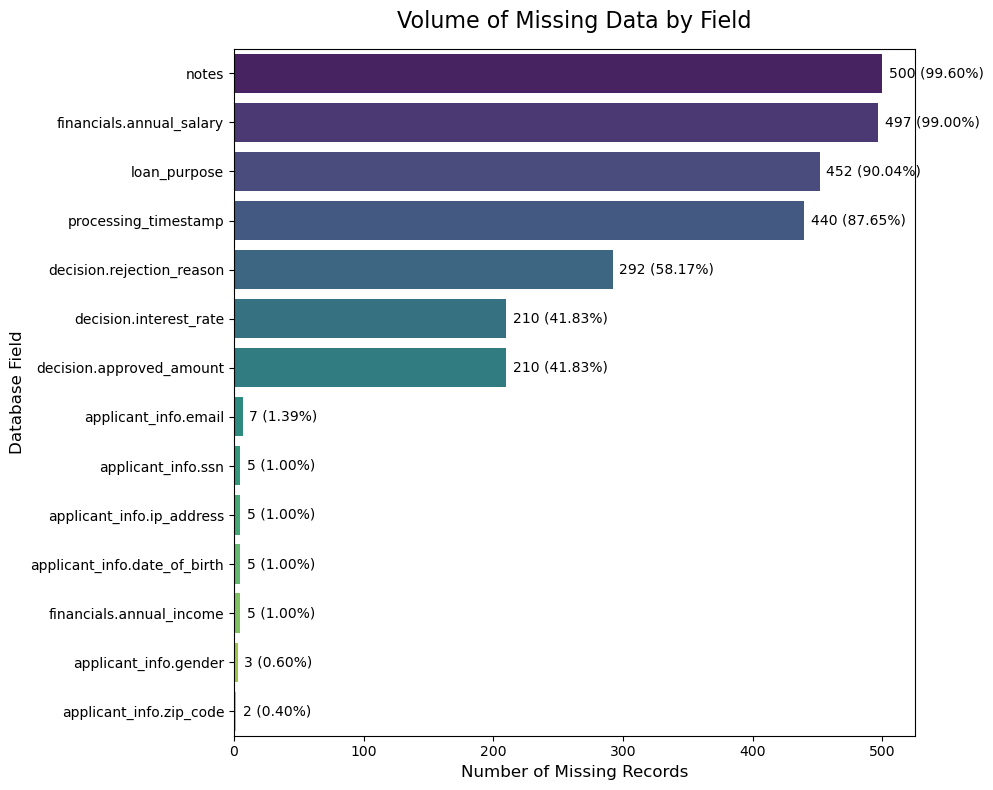

In [21]:
print("\n2. Missing Fields Analysis:")

# Define the exact schema fields based on the provided structure & what we found so far
schema_fields = [
    "app_id", # This was originally '_id'
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address",
    "applicant_info.gender",
    "applicant_info.date_of_birth",
    "applicant_info.zip_code",
    "financials.annual_income",
    "financials.annual_salary",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "spending_behavior",
    "decision.loan_approved",
    "decision.rejection_reason",
    "decision.interest_rate",
    "decision.approved_amount",
    "loan_purpose",
    "notes",
    "processing_timestamp"
]

missing_report = {}
for field in schema_fields:
    # A field is considered missing if it doesn't exist, is null, or is an empty string
    query = {
        "$or": [
            {field: {"$exists": False}},
            {field: {"$in": [None, ""]}}
        ]
    }
    
    missing_count = collection.count_documents(query)
    
    if missing_count > 0:
        missing_report[field] = missing_count
        print(f"   - {field}: {missing_count} missing ({(missing_count/total_records)*100:.2f}%)")

if not missing_report:
    print("   - No missing values found in any field.")

print("\n--- VISUALIZING MISSING FIELDS ---")

# Ensure total_records is defined from your earlier cell!
# total_records = collection.count_documents({})

if missing_report:
    df_missing = pd.DataFrame(list(missing_report.items()), columns=['Field', 'Missing Count'])
    df_missing = df_missing.sort_values(by='Missing Count', ascending=False)

    plt.figure(figsize=(10, 8))
    
    ax = sns.barplot(
        data=df_missing, 
        x='Missing Count', 
        y='Field', 
        hue='Field', 
        palette='viridis', 
        legend=False
    )
    
    plt.title('Volume of Missing Data by Field', fontsize=16, pad=15)
    plt.xlabel('Number of Missing Records', fontsize=12)
    plt.ylabel('Database Field', fontsize=12)
    
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            # Calculate the percentage exactly like your print statement
            percentage = (width / total_records) * 100
            
            # THE FIX: Changed .1f to .2f to match your earlier terminal output perfectly!
            annotation_text = f'{int(width)} ({percentage:.2f}%)'
            
            plt.text(
                width + (df_missing['Missing Count'].max() * 0.01),
                p.get_y() + p.get_height() / 2,
                annotation_text, 
                ha='left', 
                va='center', 
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

else:
    print("   - No missing values to visualize! The data is perfectly populated.")

#### 2.5 Checking For Missing Fields

The code below looks for fields that do not show up at all in the data entries despite being in the data schema. This is done to get a sense of how many fields we may need to inject to the database with null values.


3. Structurally Missing Keys Analysis:
   - applicant_info.ssn: 5 records completely missing this key (1.00%)
   - applicant_info.ip_address: 5 records completely missing this key (1.00%)
   - applicant_info.gender: 1 records completely missing this key (0.20%)
   - applicant_info.date_of_birth: 1 records completely missing this key (0.20%)
   - applicant_info.zip_code: 1 records completely missing this key (0.20%)
   - financials.annual_income: 5 records completely missing this key (1.00%)
   - financials.annual_salary: 497 records completely missing this key (99.00%)
   - decision.rejection_reason: 292 records completely missing this key (58.17%)
   - decision.interest_rate: 210 records completely missing this key (41.83%)
   - decision.approved_amount: 210 records completely missing this key (41.83%)
   - loan_purpose: 452 records completely missing this key (90.04%)
   - notes: 500 records completely missing this key (99.60%)
   - processing_timestamp: 440 records completely missi

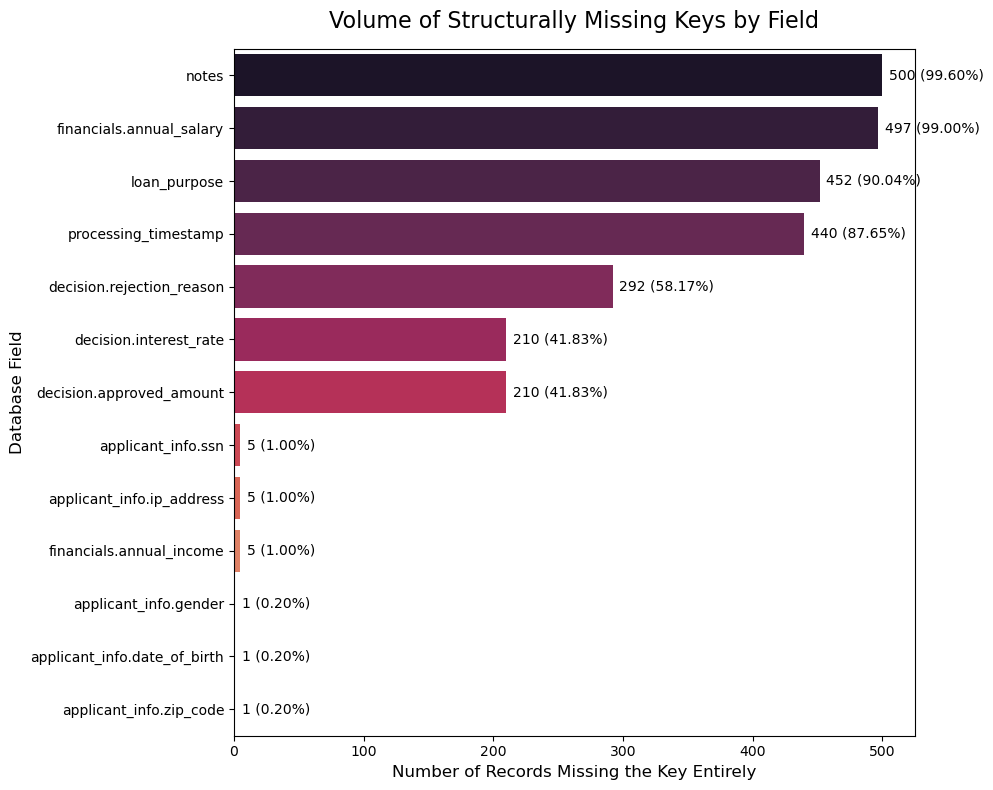

In [22]:
# Checking for when the field does not show up at all
print("\n3. Structurally Missing Keys Analysis:")

# Define all core schema fields to check

schema_fields = [
    "app_id", # This was originally '_id'
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address",
    "applicant_info.gender",
    "applicant_info.date_of_birth",
    "applicant_info.zip_code",
    "financials.annual_income",
    "financials.annual_salary",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "spending_behavior",
    "decision.loan_approved",
    "decision.rejection_reason",
    "decision.interest_rate",
    "decision.approved_amount",
    "loan_purpose",
    "notes",
    "processing_timestamp"
]

missing_keys_report = {}
total_records = collection.count_documents({})

for field in schema_fields:
    # Query: The field completely does not exist in the document hierarchy
    query = {field: {"$exists": False}}
    
    missing_key_count = collection.count_documents(query)
    
    if missing_key_count > 0:
        missing_keys_report[field] = missing_key_count
        percentage = (missing_key_count / total_records) * 100
        print(f"   - {field}: {missing_key_count} records completely missing this key ({percentage:.2f}%)")

if not missing_keys_report:
    print("   - No structurally missing keys found.")

print("\n--- VISUALIZING STRUCTURALLY MISSING KEYS ---")

# Only plot if there are actually missing keys to show
if missing_keys_report:
    # 1. Convert the report dictionary into a Pandas DataFrame
    df_missing_keys = pd.DataFrame(list(missing_keys_report.items()), columns=['Field', 'Missing Count'])
    
    # 2. Sort the data descending so the worst offenders are at the top
    df_missing_keys = df_missing_keys.sort_values(by='Missing Count', ascending=False)

    # 3. Set up the plotting canvas
    plt.figure(figsize=(10, 8))
    
    # 4. Create the horizontal barplot
    # We use hue='Field' and legend=False to comply with modern Seaborn standards
    ax = sns.barplot(
        data=df_missing_keys, 
        x='Missing Count', 
        y='Field', 
        hue='Field', 
        palette='rocket', 
        legend=False
    )
    
    # 5. Add clean titles and labels
    plt.title('Volume of Structurally Missing Keys by Field', fontsize=16, pad=15)
    plt.xlabel('Number of Records Missing the Key Entirely', fontsize=12)
    plt.ylabel('Database Field', fontsize=12) # Added this for consistency!
    
    # 6. Annotate the exact numbers AND percentages on the end of each bar
    for p in ax.patches:
        width = p.get_width()
        # Only add text if the bar actually has a width (avoids text clutter on 0 values)
        if width > 0:
            # Calculate the percentage using total_records
            percentage = (width / total_records) * 100
            
            # Format the string to match your earlier print statement
            annotation_text = f'{int(width)} ({percentage:.2f}%)'
            
            plt.text(
                width + (df_missing_keys['Missing Count'].max() * 0.01), # Slight padding
                p.get_y() + p.get_height() / 2,
                annotation_text, 
                ha='left', 
                va='center', 
                fontsize=10
            )

    # Ensure the long y-axis labels don't get cut off
    plt.tight_layout()
    plt.show()

else:
    print("   - No missing keys to visualize! The schema is perfectly intact.")

#### 2.6 Missing Values Findings and Notes

Through looking for missing values, we noted some interesting details:
- The fields `interest_rate` and `approved_amount`are missing 210 times while the field `rejection_reason` is missing 292 times. In total they make up 502, which is the number of entries in the data. This makes sense from the business perspective because approved loans don't have rejection reasons, and rejected loans don't have interest rates or approved amounts. Thus, we will not delete any entries that have missing values for these three fields.
- We find that the hidden `notes` field is nearly entirely empty for the whole dataset. Thus, we have decided to remove it during the curation phase.

#### 2.7 Checking for Inconsistent Data Types

The code below parses through all fields' data types and compares it with a dictionary created by using the data schema given in the project description documents. We are particulary looking to find disparities in the `annual_income` field.

In [23]:
print("\n4. Inconsistent Data Types Analysis:")

# Define expected BSON types for each field based on the schema.
# Note: MongoDB's "number" alias covers int, long, double, and decimal.
expected_types = {
    "app_id": "string",
    "applicant_info.full_name": "string",
    "applicant_info.email": "string",
    "applicant_info.ssn": "string",
    "applicant_info.ip_address": "string",
    "applicant_info.gender": "string",
    "applicant_info.date_of_birth": "string",
    "applicant_info.zip_code": "string",
    "financials.annual_income": "number",
    "financials.annual_salary": "number",
    "financials.credit_history_months": "number",
    "financials.debt_to_income": "number",
    "financials.savings_balance": "number",
    "spending_behavior": "array",               # Check that the parent is an array
    "spending_behavior.category": "string",     # Check elements inside the array!
    "spending_behavior.amount": "number",       # Check elements inside the array!
    "decision.loan_approved": "bool",
    "decision.rejection_reason": "string",
    "decision.interest_rate": "number",
    "decision.approved_amount": "number",
    "loan_purpose": "string",
    "notes": "string",
    "processing_timestamp": "string"
}

type_issues_report = {}

for field, expected_type in expected_types.items():
    # Query: Field exists, is NOT null/empty (handled in Part B), and does NOT match expected type
    query = {
        field: {
            "$exists": True,
            "$ne": None,
            "$ne": "",
            "$not": {"$type": expected_type}
        }
    }
    
    invalid_type_count = collection.count_documents(query)
    
    if invalid_type_count > 0:
        type_issues_report[field] = invalid_type_count
        
        # Fetch one sample to show the user exactly what the wrong data looks like
        sample_doc = collection.find_one(query)
        
        # Helper to safely extract the nested value for our print statement
        parts = field.split('.')
        sample_val = sample_doc
        for part in parts:
            if isinstance(sample_val, dict):
                sample_val = sample_val.get(part)
            elif isinstance(sample_val, list) and sample_val:
                # If it's an array (like spending_behavior), grab the first item for the sample
                sample_val = sample_val[0].get(part) if isinstance(sample_val[0], dict) else sample_val[0]

        actual_type = type(sample_val).__name__
        percentage = (invalid_type_count / total_records) * 100
        
        print(f"   - {field}: {invalid_type_count} records ({percentage:.2f}%) have incorrect type.")
        print(f"     -> Expected: '{expected_type}', Found: '{actual_type}' (Sample value: {sample_val})")

if not type_issues_report:
    print("   - No inconsistent data types found across checked fields.")


4. Inconsistent Data Types Analysis:
   - financials.annual_income: 8 records (1.59%) have incorrect type.
     -> Expected: 'number', Found: 'str' (Sample value: 55000)


#### 2.8 Checking for Inconsistent Categorical Coding

Here, we are checking the fields that contain categorical values: `gender`, `rejection_reason`, `loan_purpose` and `category` to see which categories they contain, and how many values are in each category. We are doing this to find out if there are any disparities in the categories' names. For the visualizations, we show the relative percentages of the categories in each field rather than the percentage present in the entire dataset.


5. Categorical Coding Breakdown:
   - applicant_info.gender: {'Male': 195, 'Female': 193, 'F': 58, 'M': 53, '': 2}
   - decision.rejection_reason: {'algorithm_risk_score': 170, 'insufficient_credit_history': 23, 'high_dti_ratio': 13, 'low_income': 4}
   - loan_purpose: {'medical': 8, 'education': 7, 'wedding': 6, 'debt_consolidation': 6, 'vacation': 6, 'moving': 5, 'personal': 4, 'home_improvement': 3, 'auto': 3, 'business': 2}
   - spending_behavior.category: {'Travel': 80, 'Utilities': 76, 'Entertainment': 72, 'Fitness': 71, 'Insurance': 68, 'Healthcare': 68, 'Dining': 66, 'Groceries': 65, 'Education': 64, 'Transportation': 61, 'Rent': 59, 'Shopping': 54, 'Alcohol': 11, 'Gambling': 7, 'Adult Entertainment': 5}

--- VISUALIZING CATEGORICAL BREAKDOWNS ---


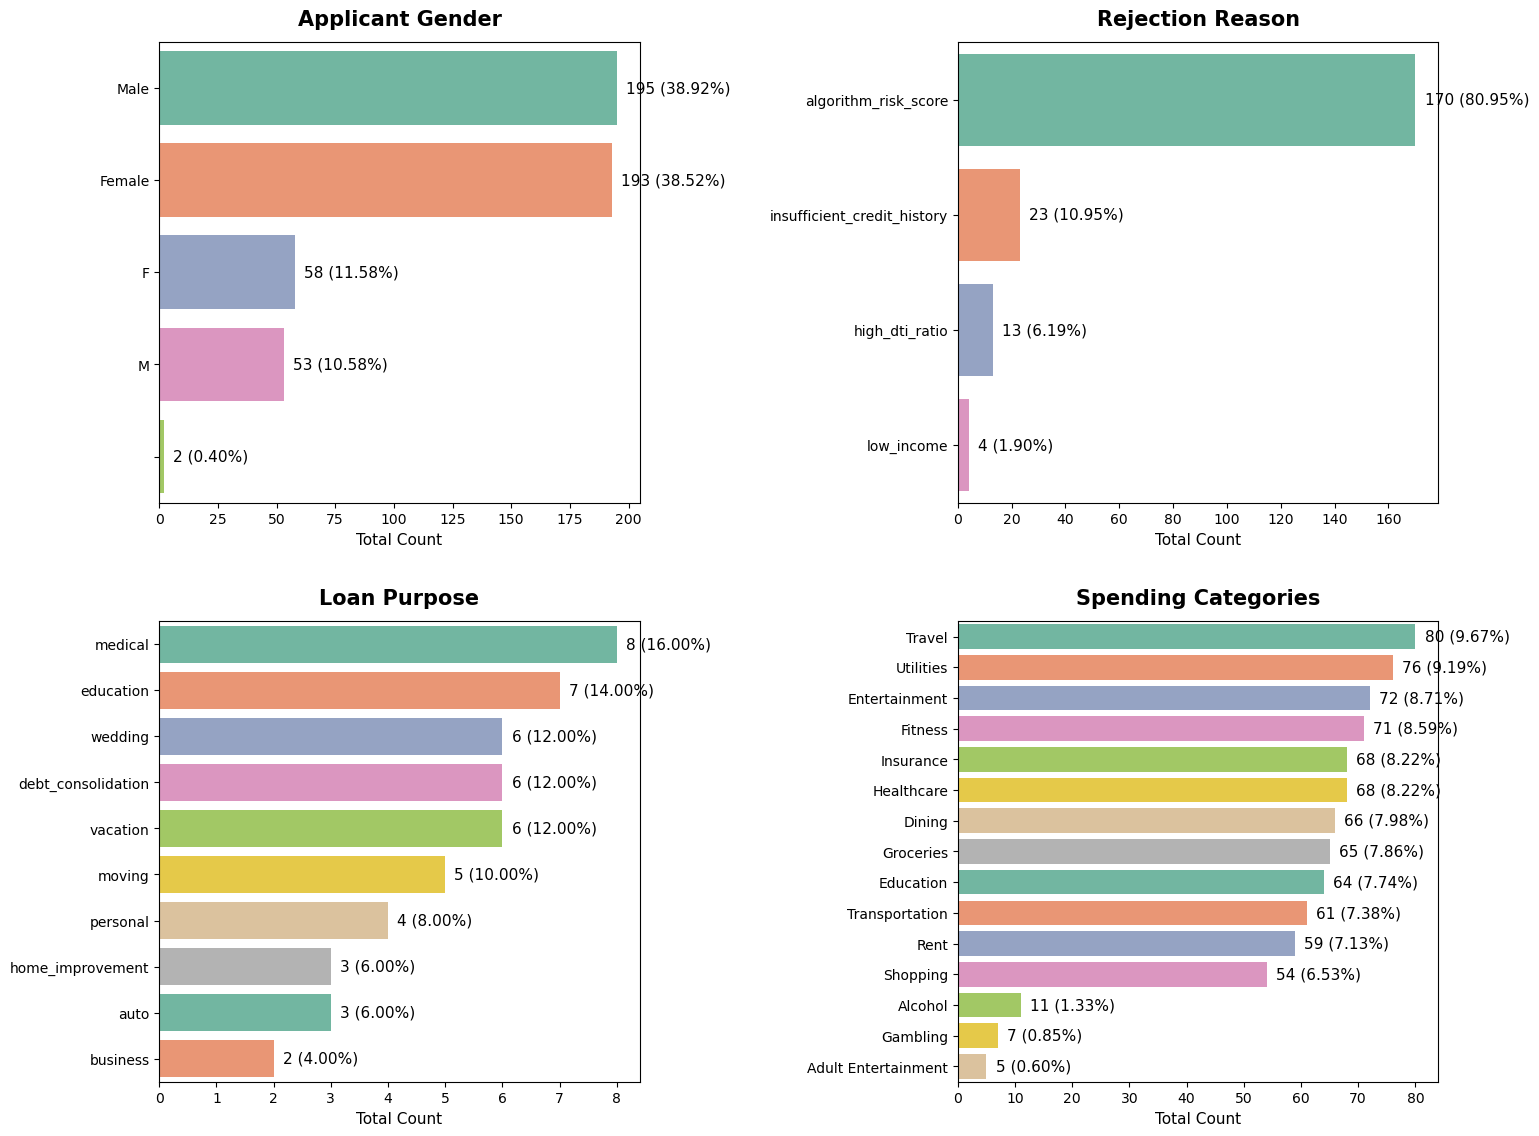

In [24]:
print("\n5. Categorical Coding Breakdown:")

categorical_fields = [
    "applicant_info.gender",
    "decision.rejection_reason",
    "loan_purpose"
]

# Standard Fields
for field in categorical_fields:
    pipeline = [
        {"$match": {field: {"$exists": True, "$ne": None}}}, # Only count existing values
        {"$group": {"_id": f"${field}", "count": {"$sum": 1}}},
        {"$sort": {"count": -1}}
    ]
    results = list(collection.aggregate(pipeline))
    breakdown = {r["_id"]: r["count"] for r in results}
    print(f"   - {field}: {breakdown}")

# Array Field (spending_behavior.category) requires $unwind
unwind_pipeline = [
    {"$unwind": "$spending_behavior"},
    {"$match": {"spending_behavior.category": {"$exists": True, "$ne": None}}},
    {"$group": {"_id": "$spending_behavior.category", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]
unwind_results = list(collection.aggregate(unwind_pipeline))
category_breakdown = {r["_id"]: r["count"] for r in unwind_results}
print(f"   - spending_behavior.category: {category_breakdown}")
print("\n--- VISUALIZING CATEGORICAL BREAKDOWNS ---")

# We map the raw database fields to clean, human-readable titles for our charts
categorical_fields = {
    "applicant_info.gender": "Applicant Gender",
    "decision.rejection_reason": "Rejection Reason",
    "loan_purpose": "Loan Purpose"
}

all_breakdowns = {}

# 1. Fetch Standard Fields
for field, title in categorical_fields.items():
    pipeline = [
        {"$match": {field: {"$exists": True, "$ne": None}}},
        {"$group": {"_id": f"${field}", "count": {"$sum": 1}}},
        {"$sort": {"count": -1}} 
    ]
    results = list(collection.aggregate(pipeline))
    all_breakdowns[title] = {str(r["_id"]): r["count"] for r in results} 

# 2. Fetch Array Field (spending_behavior.category)
unwind_pipeline = [
    {"$unwind": "$spending_behavior"},
    {"$match": {"spending_behavior.category": {"$exists": True, "$ne": None}}},
    {"$group": {"_id": "$spending_behavior.category", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]
unwind_results = list(collection.aggregate(unwind_pipeline))
all_breakdowns["Spending Categories"] = {str(r["_id"]): r["count"] for r in unwind_results}


# ==========================================
# PLOTTING THE 2x2 DASHBOARD
# ==========================================

# 3. Create a large 16x12 canvas with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 4. Loop through our 4 datasets and map them to our 4 chart spaces
for ax, (title, data_dict) in zip(axes, all_breakdowns.items()):
    
    # Convert dictionary to DataFrame
    df_cat = pd.DataFrame(list(data_dict.items()), columns=['Category', 'Count'])
    
    # Calculate the total number of records IN THIS SPECIFIC CHART for accurate percentages
    chart_total = df_cat['Count'].sum()
    
    # Create the horizontal bar chart
    sns.barplot(
        data=df_cat, 
        x='Count', 
        y='Category', 
        hue='Category', 
        palette='Set2', 
        legend=False,
        ax=ax
    )
    
    # Clean up titles and axis labels
    ax.set_title(title, fontsize=15, pad=12, fontweight='bold')
    ax.set_xlabel('Total Count', fontsize=11)
    ax.set_ylabel('') 
    
    # Add the exact value annotations and percentages to the end of each bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            # THE FIX: Calculate the percentage based on the chart_total!
            percentage = (width / chart_total) * 100
            annotation_text = f'{int(width)} ({percentage:.2f}%)'
            
            ax.text(
                width + (df_cat['Count'].max() * 0.02), 
                p.get_y() + p.get_height() / 2,
                annotation_text, 
                ha='left', 
                va='center', 
                fontsize=11
            )

# 5. Adjust layout so the 4 charts don't crowd each other
plt.tight_layout(pad=3.0)
plt.show()

#### 2.9 Inconsistent Categorical Coding Findings

We have found that only the `gender` field contains inconsistent encoding. In the data curation phase, we will map the 'M' and 'F' values to 'Male' and 'Female' respectively.

#### 2.10 Invalid & Impossible Values Analysis

For this section, we looked at the numerical fields to find any values that would not make sense (e.g. credit_history_months being less than 0). We also looked into the `email` field to see if there are any nonsensical e-mail addresses in the data. To do this, we used a regular expression of what we believe an e-mail should look like.

In [25]:
print("\n6. Invalid & Impossible Values Analysis:")

# Check for negative financial figures across all numeric fields
negative_queries = {
    "financials.credit_history_months": {"$lt": 0},
    "financials.savings_balance": {"$lt": 0},
    "financials.annual_income": {"$lt": 0},
    "financials.annual_salary": {"$lt": 0},
    "decision.approved_amount": {"$lt": 0},
    "spending_behavior.amount": {"$lt": 0} # Checks array elements automatically
}

for field, query_condition in negative_queries.items():
    query = {field: query_condition}
    count = collection.count_documents(query)
    if count > 0:
        print(f"   - {field}: {count} records have impossible negative values.")

# Check for invalid email formats using Regex
email_regex = r"^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$"
invalid_email_query = {
    "applicant_info.email": {
        "$exists": True, 
        "$not": {"$regex": email_regex}
    }
}
invalid_emails = collection.count_documents(invalid_email_query)
if invalid_emails > 0:
    print(f"   - applicant_info.email: {invalid_emails} records have badly formatted emails.")


6. Invalid & Impossible Values Analysis:
   - financials.credit_history_months: 2 records have impossible negative values.
   - financials.savings_balance: 1 records have impossible negative values.
   - applicant_info.email: 11 records have badly formatted emails.


#### 2.11 Invalid & Impossible Values Findings

We have found some impossible values in the fields `credit_history_months`, `savings_balance`and `email`. These entries will be dropped from the dataset in order to not interfere with further analysis.

#### 2.12 Invalid SSN Format Analysis

For this section, we will look at the `ssn` field to see if there are any invalid values. The format of the values in `ssn` field should be "AAA-GG-SSSS". We will use a regular expression to see if the values suit this format or not.

In [26]:
print("\n7. SSN Formatting Analysis:")

# Regex pattern for AAA-GG-SSSS
ssn_pattern = r"^\d{3}-\d{2}-\d{4}$"

# Query: The SSN exists, but it does NOT match the required pattern
invalid_ssn_query = {
    "applicant_info.ssn": {
        "$exists": True, 
        "$ne": None,       # Ignore missing ones (already handled in Part B)
        "$not": {"$regex": ssn_pattern}
    }
}

invalid_ssn_count = collection.count_documents(invalid_ssn_query)

if invalid_ssn_count > 0:
    print(f"   - applicant_info.ssn: {invalid_ssn_count} records have an incorrectly formatted SSN.")
    
    # Grab a sample to see what the bad data looks like
    sample_bad_ssn = collection.find_one(invalid_ssn_query)
    print(f"     -> Example of bad SSN found: '{sample_bad_ssn['applicant_info']['ssn']}'")
else:
    print("   - All existing SSNs are perfectly formatted as AAA-GG-SSSS.")


7. SSN Formatting Analysis:
   - All existing SSNs are perfectly formatted as AAA-GG-SSSS.


#### 2.13 Invalid SSN Format Findings

Since all existing `ssn` values in the dataset are correctly formatted, we will not do any manipulation to this field. 

#### 2.14 Inconsistent Date Formatting Analysis

We will look into the two fields with date information for this section: `date_of_birth` and `processing_timestamp`. We will try to find values that do not match the correct format contained in the regular expressions we generated for each of them.

In [27]:
print("\n8. Date Formatting Analysis:")

# Regex for standard YYYY-MM-DD (e.g., 1990-12-31)
dob_standard_pattern = r"^\d{4}-\d{2}-\d{2}$"

# Regex for standard ISO 8601 Timestamp (e.g., 2024-01-15T00:00:00Z)
timestamp_standard_pattern = r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}Z$"

# 1. Query for inconsistent Date of Birth
invalid_dob_query = {
    "applicant_info.date_of_birth": {
        "$exists": True, 
        "$ne": None,
        "$not": {"$regex": dob_standard_pattern}
    }
}
invalid_dob_count = collection.count_documents(invalid_dob_query)
if invalid_dob_count > 0:
    print(f"   - date_of_birth: {invalid_dob_count} records do not match 'YYYY-MM-DD'.")
    
# 2. Query for inconsistent Processing Timestamp
invalid_timestamp_query = {
    "processing_timestamp": {
        "$exists": True, 
        "$ne": None,
        "$not": {"$regex": timestamp_standard_pattern}
    }
}
invalid_timestamp_count = collection.count_documents(invalid_timestamp_query)
if invalid_timestamp_count > 0:
    print(f"   - processing_timestamp: {invalid_timestamp_count} records do not match ISO 8601 format.")
else:
    print("   - processing_timestamp: All existing records match ISO 8601 format.")


8. Date Formatting Analysis:
   - date_of_birth: 161 records do not match 'YYYY-MM-DD'.
   - processing_timestamp: All existing records match ISO 8601 format.


#### 2.15 Inconsistent Date Formatting Findings

Here, we see that the `date_of_birth`field will require manipulation during the data curation phase.

#### 2.16 Invalid Date Analysis for Placeholder Values

In this section we once again look into the date fields `date_of_birth` and `processing_timestamp`to see if they contain any invalid values such as '1970-01-01T00:00:00Z', which we will use as placeholders to denote missing values.

In [28]:
print("\n9. Placeholder/Invalid Dates Analysis")

# Check processing_timestamp for the 1970 Unix Epoch
epoch_query = {"processing_timestamp": "1970-01-01T00:00:00Z"}
epoch_count = collection.count_documents(epoch_query)

if epoch_count > 0:
    print(f" -> Alert: Found {epoch_count} records with processing_timestamp = '1970-01-01T00:00:00Z'")
else:
    print(" -> Clean: No 1970 epoch timestamps found.")

# Check date_of_birth for 1900 placeholder (and 1970 just in case)
dob_query = {
    "applicant_info.date_of_birth": {
        "$in": ["1900-01-01", "1970-01-01", "1970-01-01T00:00:00Z"]
    }
}
dob_count = collection.count_documents(dob_query)

if dob_count > 0:
    print(f" -> Alert: Found {dob_count} records with a placeholder date_of_birth ('1900-01-01' or '1970-01-01').")
else:
    print(" -> Clean: No placeholder birthdays found.")


9. Placeholder/Invalid Dates Analysis
 -> Clean: No 1970 epoch timestamps found.
 -> Clean: No placeholder birthdays found.


### 3.0 DATA CURATION

#### 3.1 Delete Duplicates

In [29]:
# Prepare the deletion operations
bulk_operations = []

for duplicate_group in duplicates:
    # duplicate_ids contains all identical records. 
    # We slice the list [1:] to keep the first record and delete the rest.
    ids_to_delete = duplicate_group['duplicate_ids'][1:]
    
    for mongo_id in ids_to_delete:
        bulk_operations.append(DeleteOne({"_id": mongo_id}))

# Execute the deletions in a single batch
if bulk_operations:
    result = collection.bulk_write(bulk_operations)
    print(f"Success! duplicates resolved.")
    print(f" -> Documents permanently deleted: {result.deleted_count}")
else:
    print("No strict duplicates found to remediate.")

Success! duplicates resolved.
 -> Documents permanently deleted: 1


#### 3.2 Delete Entries with Invalid or Impossible Values

In [30]:
print("\n--- DELETING RECORDS WITH IMPOSSIBLE VALUES & BAD EMAILS ---")

# 1. Dictionary of our negative value queries
negative_queries = {
    "financials.credit_history_months": {"$lt": 0},
    "financials.savings_balance": {"$lt": 0},
    "financials.annual_income": {"$lt": 0},
    "financials.annual_salary": {"$lt": 0},
    "decision.approved_amount": {"$lt": 0},
    "spending_behavior.amount": {"$lt": 0} 
}

total_deleted_financials = 0

# Loop through and delete
for field, query_condition in negative_queries.items():
    query = {field: query_condition}
    result = collection.delete_many(query)
    
    if result.deleted_count > 0:
        print(f" -> Deleted {result.deleted_count} records due to negative '{field}'.")
        total_deleted_financials += result.deleted_count

# 2. Delete badly formatted emails
email_regex = r"^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$"
invalid_email_query = {
    "applicant_info.email": {
        "$exists": True, 
        "$type": "string", # Ensures we only check string types
        "$not": {"$regex": email_regex}
    }
}

email_result = collection.delete_many(invalid_email_query)
if email_result.deleted_count > 0:
    print(f" -> Deleted {email_result.deleted_count} records due to badly formatted emails.")

# Summary
total_purged = total_deleted_financials + email_result.deleted_count
print(f"\nTotal invalid records successfully purged from database: {total_purged}")


--- DELETING RECORDS WITH IMPOSSIBLE VALUES & BAD EMAILS ---
 -> Deleted 2 records due to negative 'financials.credit_history_months'.
 -> Deleted 1 records due to negative 'financials.savings_balance'.
 -> Deleted 11 records due to badly formatted emails.

Total invalid records successfully purged from database: 14


#### 3.3. Map annual_salary to annual_income and drop notes

In [31]:
print("\n--- STANDARDIZING SCHEMA: SALARY & NOTES ---")

# 1. Drop the 'notes' field globally
# We use update_many to instantly wipe this field from any document that has it.
notes_update_result = collection.update_many(
    {"notes": {"$exists": True}},
    {"$unset": {"notes": ""}}  # $unset permanently removes the key
)
print(f" -> Dropped 'notes' field from {notes_update_result.modified_count} documents.")


# 2. Map 'annual_salary' to 'annual_income' and drop 'annual_salary'
# We fetch only the documents that contain the rogue 'annual_salary' key
salary_docs = collection.find({"financials.annual_salary": {"$exists": True}})
bulk_operations = []

for doc in salary_docs:
    # Extract the value from the wrong key
    salary_value = doc['financials']['annual_salary']
    
    # Create an update operation that sets the new key AND unsets the old key simultaneously
    bulk_operations.append(
        pymongo.UpdateOne(
            {"_id": doc['_id']},
            {
                "$set": {"financials.annual_income": salary_value},
                "$unset": {"financials.annual_salary": ""}
            }
        )
    )

# Execute the mapping operations in a single batch
if bulk_operations:
    salary_result = collection.bulk_write(bulk_operations)
    print(f" -> Mapped 'annual_salary' to 'annual_income' in {salary_result.modified_count} documents.")
else:
    print(" -> No 'annual_salary' fields found to map.")


--- STANDARDIZING SCHEMA: SALARY & NOTES ---
 -> Dropped 'notes' field from 1 documents.
 -> Mapped 'annual_salary' to 'annual_income' in 5 documents.


#### 3.4 Verifying of Mapping for annual_salary to annual_income

In [32]:
# Verify 'notes' and 'annual_salary' are completely gone
print("Count of 'notes':", collection.count_documents({"notes": {"$exists": True}}))
print("Count of 'annual_salary':", collection.count_documents({"financials.annual_salary": {"$exists": True}}))

# Verify 'annual_income' exists for every single record
total_docs = collection.count_documents({})
income_docs = collection.count_documents({"financials.annual_income": {"$exists": True}})

print(f"Total documents: {total_docs}")
print(f"Documents with 'annual_income': {income_docs}")

Count of 'notes': 0
Count of 'annual_salary': 0
Total documents: 487
Documents with 'annual_income': 487


#### 3.5 Standardizing date_of_birth

In [33]:
print("\n--- STANDARDIZING DATE FORMATS: DATE OF BIRTH ---")

# Regex pattern for the strict standard we want: exactly YYYY-MM-DD
dob_standard_pattern = r"^\d{4}-\d{2}-\d{2}$"

# Query MongoDB to fetch ONLY the 161 records that violate the standard format
invalid_dob_docs = collection.find({
    "applicant_info.date_of_birth": {
        "$exists": True, 
        "$ne": None,
        "$not": {"$regex": dob_standard_pattern}
    }
})

bulk_operations = []

# List of common date formats we discovered during profiling
possible_formats = [
    '%m/%d/%Y',  # e.g., 12/31/1990
    '%m/%d/%y',  # e.g., 12/31/90
    '%d/%m/%Y',  # e.g., 31/12/1990 (EU format)
    '%d/%m/%y',  # e.g., 31/12/90
    '%Y/%m/%d',  # e.g., 1990/12/31
    '%m-%d-%Y',  # e.g., 12-31-1990
    '%m-%d-%y'   # e.g., 12-31-90
]

for doc in invalid_dob_docs:
    doc_mongo_id = doc['_id']
    dob = doc['applicant_info']['date_of_birth']
    
    if isinstance(dob, str):
        parsed_date = None
        
        # Try parsing the string against our list of known candidate formats
        for fmt in possible_formats:
            try:
                parsed_date = datetime.strptime(dob, fmt)
                break  # Stop trying formats as soon as we get a successful match
            except ValueError:
                continue
        
        if parsed_date:
            # Reformat the parsed datetime object into our strict YYYY-MM-DD string
            standardized_dob = parsed_date.strftime('%Y-%m-%d')
            
            bulk_operations.append(
                pymongo.UpdateOne(
                    {"_id": doc_mongo_id},
                    {"$set": {"applicant_info.date_of_birth": standardized_dob}}
                )
            )
        else:
            # If the string is complete gibberish and cannot be parsed by any format, 
            # we fall back to the default placeholder we used in our missing keys step.
            bulk_operations.append(
                pymongo.UpdateOne(
                    {"_id": doc_mongo_id},
                    {"$set": {"applicant_info.date_of_birth": "1900-01-01"}} 
                )
            )

# Execute the updates in a single batch
if bulk_operations:
    result = collection.bulk_write(bulk_operations)
    print(f" -> Successfully standardized 'date_of_birth' in {result.modified_count} documents.")
else:
    print(" -> No 'date_of_birth' records needed standardization.")


--- STANDARDIZING DATE FORMATS: DATE OF BIRTH ---
 -> Successfully standardized 'date_of_birth' in 157 documents.


#### 3.6 Inject Default Placeholders for Missing Keys

For fields with missing values which we do not want to delete completely from the database, we will inject default placeholders. This will also make parsing of the database easier, so further deletions can be implemented.

In [34]:
# Define our standard fallback values based on the expected data types
default_placeholders = {
    "applicant_info.ssn": "000-00-0000",           # Standard invalid SSN placeholder
    "applicant_info.ip_address": "0.0.0.0",        # Standard generic IP
    "applicant_info.gender": "Unknown",
    "applicant_info.date_of_birth": "1900-01-01",  # Standard fallback date (ISO 8601)
    "applicant_info.zip_code": "00000",
    "financials.annual_income": 0.0,               # Safe numeric fallback
    "decision.rejection_reason": "Not Applicable", # For loans that were approved
    "decision.interest_rate": 0.0,                 # For loans that were rejected
    "decision.approved_amount": 0.0,               # For loans that were rejected
    "loan_purpose": "Not Specified",               # Categorical fallback
    "processing_timestamp": "1970-01-01T00:00:00Z" # Standard Unix epoch fallback
}

total_updates = 0

# Iterate through our dictionary and execute a mass update for each missing key
for field, default_val in default_placeholders.items():
    # Query: Find documents where this specific key does NOT exist
    query = {field: {"$exists": False}}
    
    # Update: Set the key to our predefined default placeholder
    update = {"$set": {field: default_val}}
    
    # update_many applies the fix to all matching documents in a single database call
    result = collection.update_many(query, update)
    
    if result.modified_count > 0:
        total_updates += result.modified_count
        print(f" -> Injected placeholder '{default_val}' for '{field}' in {result.modified_count} documents.")

print(f"\nMissing key injection complete! Total fields populated: {total_updates}")

 -> Injected placeholder '000-00-0000' for 'applicant_info.ssn' in 1 documents.
 -> Injected placeholder '0.0.0.0' for 'applicant_info.ip_address' in 1 documents.
 -> Injected placeholder 'Unknown' for 'applicant_info.gender' in 1 documents.
 -> Injected placeholder '1900-01-01' for 'applicant_info.date_of_birth' in 1 documents.
 -> Injected placeholder '00000' for 'applicant_info.zip_code' in 1 documents.
 -> Injected placeholder 'Not Applicable' for 'decision.rejection_reason' in 282 documents.
 -> Injected placeholder '0.0' for 'decision.interest_rate' in 205 documents.
 -> Injected placeholder '0.0' for 'decision.approved_amount' in 205 documents.
 -> Injected placeholder 'Not Specified' for 'loan_purpose' in 438 documents.
 -> Injected placeholder '1970-01-01T00:00:00Z' for 'processing_timestamp' in 428 documents.

Missing key injection complete! Total fields populated: 1563


#### 3.7 Deletion of Records with Placeholder Birthdays

During the Data Scientist's step, it became clear that age is an important value for conducting necessary analysis. Thus, we will delete the entries that previously had missing values for the `date_of_birth` field (currently, they contain the default placeholder value "1900-01-01")

In [35]:
result = collection.delete_many({"applicant_info.date_of_birth": "1900-01-01"})

print(f"Deleted {result.deleted_count} invalid applications missing a true Date of Birth.")

Deleted 1 invalid applications missing a true Date of Birth.


#### 3.8 Standardizing annual_income to float

In [36]:
# Fetch all documents that have an annual_income field
docs_with_income = collection.find({"financials.annual_income": {"$exists": True}})
bulk_operations = []

for doc in docs_with_income:
    doc_mongo_id = doc['_id']
    income = doc['financials']['annual_income']
    
    new_income_value = None
    
    # 1. Handle Strings
    if isinstance(income, str):
        try:
            # Strip out any commas, dollar signs, or spaces, then cast to float
            clean_string = re.sub(r'[^\d.]', '', income)
            new_income_value = float(clean_string)
        except ValueError:
            # If the string is completely unparseable (e.g. "Unknown"), we can set it to a default or None
            new_income_value = 0.0 
            
    # 2. Handle Integers (and natively recast existing floats just to be safe)
    elif isinstance(income, (int, float)):
        new_income_value = float(income)

    # If we successfully parsed a new value, and it strictly needs updating
    # (Checking type ensures we don't unnecessarily update existing floats)
    if new_income_value is not None and type(income) is not float:
        bulk_operations.append(
            pymongo.UpdateOne(
                {"_id": doc_mongo_id},
                {"$set": {"financials.annual_income": new_income_value}}
            )
        )

# Execute the type casting in a single batch
if bulk_operations:
    result = collection.bulk_write(bulk_operations)
    print(f" -> Successfully converted 'annual_income' to float in {result.modified_count} documents.")
else:
    print(" -> All 'annual_income' fields are already correctly formatted as floats.")

 -> Successfully converted 'annual_income' to float in 485 documents.


#### 3.9 Standardizing Gender Encoding

We will map "M" and "F" values to "Male" and "Female" respectively. The blank value "" will be mapped to "Unknown".

In [37]:
print("\n--- STANDARDIZING CATEGORICAL DATA: GENDER ---")

# 1. Fix 'M' -> 'Male'
result_m = collection.update_many(
    {"applicant_info.gender": "M"},
    {"$set": {"applicant_info.gender": "Male"}}
)
print(f" -> Converted 'M' to 'Male' in {result_m.modified_count} documents.")

# 2. Fix 'F' -> 'Female'
result_f = collection.update_many(
    {"applicant_info.gender": "F"},
    {"$set": {"applicant_info.gender": "Female"}}
)
print(f" -> Converted 'F' to 'Female' in {result_f.modified_count} documents.")

# 3. Fix '' (empty string) -> 'Unknown'
result_empty = collection.update_many(
    {"applicant_info.gender": ""},
    {"$set": {"applicant_info.gender": "Unknown"}}
)
print(f" -> Converted empty strings '' to 'Unknown' in {result_empty.modified_count} documents.")

# 4. Optional: Verify the final clean state
pipeline = [
    {"$match": {"applicant_info.gender": {"$exists": True}}},
    {"$group": {"_id": "$applicant_info.gender", "count": {"$sum": 1}}}
]
final_genders = list(collection.aggregate(pipeline))
clean_breakdown = {g["_id"]: g["count"] for g in final_genders}

print(f"\nFinal cleaned gender breakdown: {clean_breakdown}")


--- STANDARDIZING CATEGORICAL DATA: GENDER ---
 -> Converted 'M' to 'Male' in 53 documents.
 -> Converted 'F' to 'Female' in 58 documents.
 -> Converted empty strings '' to 'Unknown' in 0 documents.

Final cleaned gender breakdown: {'Female': 244, 'Male': 242}


#### 3.10 Deleting "Unknown" Gender

During the Data Scientiest's step, it became clear that we will use the `gender`field to conduct analysis using the "Female" and "Male" values, thus the entry with the value "Unknown" will be deleted.

In [38]:
# Delete the records with 'Unknown' gender
result = collection.delete_many({"applicant_info.gender": "Unknown"})

print(f"Deleted {result.deleted_count} applications with an 'Unknown' gender.")

Deleted 0 applications with an 'Unknown' gender.


### 4.0 Data Exportation

#### 4.1 Export to json

We will export the curated data into a JSON file.

In [39]:
print("\n--- EXPORTING CURATED DATA TO JSON ---")

# Fetch all documents from the cleaned collection
# We use find({}) to get everything.
cursor = collection.find({})

cleaned_data = []

for doc in cursor:
    # Remove the internal MongoDB ObjectId
    # MongoDB automatically adds an '_id' object to every document. 
    # Since we mapped '_id' to 'app_id', we can safely drop the MongoDB one.
    if '_id' in doc:
        del doc['_id']
        
    cleaned_data.append(doc)

# Write the list of dictionaries to a new JSON file
output_filename = 'processed_credit_applications.json'

with open(output_filename, 'w') as f:
    # indent=2 makes the JSON file nicely formatted and human-readable
    json.dump(cleaned_data, f, indent=2)

print(f"Success! Exported {len(cleaned_data)} fully curated records to '{output_filename}'.")


--- EXPORTING CURATED DATA TO JSON ---
Success! Exported 486 fully curated records to 'processed_credit_applications.json'.


#### 4.2 Export to CSV and Add Age Column

Upon the Data Scientist's request, the data was exported into a CSV file, and an `age` column was added, calculated using `date_of_birth`

In [40]:
print("--- CONVERTING PROCESSED JSON TO CSV ---")

# 1. Load your perfectly clean 494-row JSON file
with open('processed_credit_applications.json', 'r') as f:
    data = json.load(f)

# 2. Flatten the nested JSON structure into a tabular DataFrame
df = pd.json_normalize(data)

# 3. Convert the date_of_birth column to proper Pandas datetime objects
# We don't need errors='coerce' or dropna() because your dates are already clean!
df['applicant_info.date_of_birth'] = pd.to_datetime(df['applicant_info.date_of_birth'])

# 4. Calculate the Age Column
today = pd.to_datetime('today')
df['age'] = (today - df['applicant_info.date_of_birth']).dt.days // 365

# 5. Export to CSV
csv_filename = 'credit_applications_with_age.csv'
df.to_csv(csv_filename, index=False)

print(f"Success! Data exported to '{csv_filename}'.")
print(f"Total rows in DataFrame: {len(df)}")

--- CONVERTING PROCESSED JSON TO CSV ---
Success! Data exported to 'credit_applications_with_age.csv'.
Total rows in DataFrame: 486
